In [101]:
# ============================================================
# Cell 1: Imports and Global Configuration (CALIBRATED)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os, sys, json, time
from scipy.spatial import cKDTree
from tqdm.notebook import tqdm
from numba import njit, prange
from math import erfc, exp, sqrt, pi, log
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# ===================== Physical Constants =====================
kB_eV = 8.617333262145e-5          # Boltzmann constant (eV/K)
NA = 6.02214076e23                 # Avogadro's number

# ===================== CALIBRATED Simulation Settings =====================
TEMPERATURE_STAGES = [4000, 3000, 2000, 1500, 1000, 500, 300]
STEPS_PER_STAGE = 2000
TOTAL_STEPS = len(TEMPERATURE_STAGES) * STEPS_PER_STAGE

# ⭐ CALIBRATED BOX for density = 2.2 g/cm³
BOX_LENGTH = 31.98                 # Å (calibrated from 1960 atoms)
TARGET_DENSITY = 2.2               # g/cm³

# NVT ensemble (no pressure, fixed volume)
P_TARGET = 0.0                     # GPa

CUTOFF = 10.0                      # Å
COULOMB_CUTOFF = 10.0              # Å
WOLF_ALPHA = 0.2                   # Å⁻¹

SKIN = 1.0                         # Å
NEIGHBOR_UPDATE_FREQ = 25

DISPLACEMENT_MAX = 0.1
VOLUME_MOVE_PROB = 0.0             # ⭐ DISABLED for NVT

TRAJ_OUTPUT_FREQ = 20

SEED = 42
rng = np.random.default_rng(SEED)

print("=" * 60)
print("CALIBRATED NVT SIMULATION CONFIGURATION")
print("=" * 60)
print(f"Box length: {BOX_LENGTH:.2f} Å (calibrated)")
print(f"Target density: {TARGET_DENSITY:.2f} g/cm³")
print(f"Temperature stages: {len(TEMPERATURE_STAGES)}")
print(f"Total MC steps: {TOTAL_STEPS}")
print(f"Cutoff: {CUTOFF} Å | Wolf α: {WOLF_ALPHA}")
print(f"Volume moves: DISABLED (NVT ensemble)")
print("=" * 60)

CALIBRATED NVT SIMULATION CONFIGURATION
Box length: 31.98 Å (calibrated)
Target density: 2.20 g/cm³
Temperature stages: 7
Total MC steps: 14000
Cutoff: 10.0 Å | Wolf α: 0.2
Volume moves: DISABLED (NVT ensemble)


In [102]:
# ============================================================
# Cell 2: Parse Ternary.txt
# ============================================================
def parse_ternary_file(filename="Ternary.txt"):
    """
    Read structure file and extract atom types, coordinates.
    Automatically wraps coordinates into simulation box.
    """
    with open(filename, 'r') as f:
        lines = f.readlines()
    
    n_atoms = int(lines[0].strip())
    data_lines = lines[2:2+n_atoms]
    
    atom_symbols = []
    coords_list = []
    
    for line in data_lines:
        parts = line.strip().split()
        if len(parts) >= 4:
            elem = parts[0]
            x, y, z = map(float, parts[1:4])
            atom_symbols.append(elem)
            coords_list.append([x, y, z])
    
    coords = np.array(coords_list, dtype=np.float64)
    
    # Wrap coordinates into box [0, BOX_LENGTH)
    coords = coords % BOX_LENGTH
    
    # Create type mapping
    unique_elements = sorted(set(atom_symbols))
    type_map = {el: i for i, el in enumerate(unique_elements)}
    type_indices = np.array([type_map[el] for el in atom_symbols], dtype=np.int32)
    
    print(f"Successfully parsed {len(atom_symbols)} atoms")
    print("Element composition:")
    for el in unique_elements:
        count = atom_symbols.count(el)
        print(f"  {el}: {count} atoms")
    print(f"Type mapping: {type_map}")
    print(f"Coordinate range: "
          f"[{coords[:,0].min():.2f}, {coords[:,0].max():.2f}] × "
          f"[{coords[:,1].min():.2f}, {coords[:,1].max():.2f}] × "
          f"[{coords[:,2].min():.2f}, {coords[:,2].max():.2f}]")
    
    return atom_symbols, coords, type_indices, type_map

# Execute parsing
atom_symbols, coords, type_indices, type_map = parse_ternary_file("Ternary.txt")
n_atoms = len(atom_symbols)

Successfully parsed 1960 atoms
Element composition:
  Ca: 252 atoms
  O: 1232 atoms
  P: 56 atoms
  Si: 420 atoms
Type mapping: {'Ca': 0, 'O': 1, 'P': 2, 'Si': 3}
Coordinate range: [0.46, 30.54] × [0.46, 30.54] × [0.46, 30.55]


In [103]:
# ============================================================
# Cell 3: Buckingham Parameters
# ============================================================
def load_buckingham_parameters(param_file=None):
    """
    Load Buckingham parameters.
    Uses literature values for SiO₂–CaO–P₂O₅ glass system.
    """
    if param_file and os.path.isfile(param_file):
        with open(param_file, 'r') as f:
            params_dict = json.load(f)
        return {tuple(k.split('-')): v for k, v in params_dict.items()}
    
    # Validated literature parameters
    default_params = {
        ('Si', 'O'): {'A': 1283.907,  'rho': 0.3205, 'C': 10.44},
        ('Ca', 'O'): {'A': 1272.7,    'rho': 0.2985, 'C': 0.0},
        ('P', 'O') : {'A': 900.0,     'rho': 0.33,   'C': 10.0},
        ('O', 'O') : {'A': 22764.0,   'rho': 0.149,  'C': 27.88}
    }
    return default_params

# Load parameters
buck_params = load_buckingham_parameters()

print("Buckingham parameters loaded:")
print(f"{'Pair':<12} {'A (eV)':<12} {'rho (Å)':<10} {'C (eV·Å⁶)':<12}")
print("-" * 46)
for (el1, el2), p in buck_params.items():
    print(f"{el1}-{el2:<9} {p['A']:<12.2f} {p['rho']:<10.4f} {p['C']:<12.2f}")

Buckingham parameters loaded:
Pair         A (eV)       rho (Å)    C (eV·Å⁶)   
----------------------------------------------
Si-O         1283.91      0.3205     10.44       
Ca-O         1272.70      0.2985     0.00        
P-O         900.00       0.3300     10.00       
O-O         22764.00     0.1490     27.88       


In [104]:
# ============================================================
# Cell 4: Charge Assignment
# ============================================================
# Partial charges ensuring overall neutrality
charge_dict = {
    'Si': 2.4,   # +2.4 e
    'Ca': 1.2,   # +1.2 e
    'P' : 3.0,   # +3.0 e
    'O' : -1.2   # -1.2 e
}

# Build charge array matching atom order
charges = np.array([charge_dict[sym] for sym in atom_symbols], dtype=np.float64)

# Verify neutrality
total_charge = np.sum(charges)

print("Charge assignment:")
for el, q in charge_dict.items():
    count = atom_symbols.count(el)
    if count > 0:
        print(f"  {el}: {q:+.1f} e × {count:4d} atoms = {q*count:+8.2f} e")
print(f"\nTotal system charge: {total_charge:.6f} e")

assert abs(total_charge) < 1e-6, "ERROR: System is not charge-neutral!"
print("✓ System is charge-neutral")

Charge assignment:
  Si: +2.4 e ×  420 atoms = +1008.00 e
  Ca: +1.2 e ×  252 atoms =  +302.40 e
  P: +3.0 e ×   56 atoms =  +168.00 e
  O: -1.2 e × 1232 atoms = -1478.40 e

Total system charge: 0.000000 e
✓ System is charge-neutral


In [105]:
# ============================================================
# Cell 5: Interaction Matrices & Verlet Neighbor List
# ============================================================
# --- Build type-indexed parameter matrices ---
num_types = len(type_map)
A_mat = np.zeros((num_types, num_types))
rho_mat = np.zeros((num_types, num_types))
C_mat = np.zeros((num_types, num_types))

for (el1, el2), params in buck_params.items():
    t1 = type_map[el1]
    t2 = type_map[el2]
    A_mat[t1, t2] = params['A']
    rho_mat[t1, t2] = params['rho']
    C_mat[t1, t2] = params['C']
    if t1 != t2:
        A_mat[t2, t1] = params['A']
        rho_mat[t2, t1] = params['rho']
        C_mat[t2, t1] = params['C']

print("Pairwise parameter matrices built:")
print(f"  Types: {type_map}")
print(f"  A matrix shape: {A_mat.shape}")

# --- Neighbor list functions ---
def build_neighbor_list(coords, box_size, cutoff, skin):
    """
    Build Verlet neighbor list using cKDTree with PBC.
    
    Returns
    -------
    pairs : ndarray (M, 2)
        Pairs of atom indices within cutoff + skin
    wrapped_coords : ndarray (N, 3)
        Coordinates wrapped into primary box
    """
    # Ensure boxsize is proper array
    if np.isscalar(box_size):
        boxsize = np.array([box_size, box_size, box_size], dtype=np.float64)
    else:
        boxsize = np.asarray(box_size, dtype=np.float64)
    
    box_L = boxsize[0]
    
    # Wrap coordinates
    wrapped_coords = coords % box_L
    
    # Build tree and query pairs
    tree = cKDTree(wrapped_coords, boxsize=boxsize)
    pairs = tree.query_pairs(cutoff + skin, output_type='ndarray')
    
    return pairs, wrapped_coords

def update_adjacency(pairs, n_atoms):
    """
    Convert pair list to adjacency list for fast local energy calculation.
    """
    adjacency = [set() for _ in range(n_atoms)]
    for i, j in pairs:
        adjacency[i].add(j)
        adjacency[j].add(i)
    # Convert to sorted arrays
    adjacency = [np.array(sorted(list(neighbors)), dtype=np.int32) 
                 for neighbors in adjacency]
    return adjacency

# Build initial neighbor list
neighbor_pairs, coords = build_neighbor_list(coords, BOX_LENGTH, CUTOFF, SKIN)
neighbor_adj = update_adjacency(neighbor_pairs, n_atoms)

# Statistics
n_pairs = neighbor_pairs.shape[0]
n_neighbors_per_atom = [len(adj) for adj in neighbor_adj]

print(f"\nInitial neighbor list:")
print(f"  Total pairs: {n_pairs}")
print(f"  Cutoff + skin: {CUTOFF + SKIN:.1f} Å")
print(f"  Neighbors per atom: min={min(n_neighbors_per_atom)}, "
      f"max={max(n_neighbors_per_atom)}, "
      f"mean={np.mean(n_neighbors_per_atom):.1f}")

Pairwise parameter matrices built:
  Types: {'Ca': 0, 'O': 1, 'P': 2, 'Si': 3}
  A matrix shape: (4, 4)

Initial neighbor list:
  Total pairs: 330764
  Cutoff + skin: 11.0 Å
  Neighbors per atom: min=264, max=411, mean=337.5


In [106]:
# ============================================================
# Cell 6: Total Energy Calculation (Buckingham + Wolf)
# ============================================================
@njit(parallel=False, fastmath=True)
def compute_total_energy(coords, charges, type_indices, A_mat, rho_mat, C_mat,
                         neighbor_pairs, box_size, cutoff, wolf_alpha):
    """
    Compute total pair energy: Buckingham + Wolf-shifted Coulomb.
    Uses minimum image convention for PBC.
    """
    n_pairs = neighbor_pairs.shape[0]
    energy = 0.0
    
    # Precompute Wolf shift constant
    wolf_shift = erfc(wolf_alpha * cutoff) / cutoff
    
    for p in range(n_pairs):
        i = neighbor_pairs[p, 0]
        j = neighbor_pairs[p, 1]
        
        # Displacement with minimum image convention
        dx = coords[i, 0] - coords[j, 0]
        dy = coords[i, 1] - coords[j, 1]
        dz = coords[i, 2] - coords[j, 2]
        
        dx = dx - box_size * round(dx / box_size)
        dy = dy - box_size * round(dy / box_size)
        dz = dz - box_size * round(dz / box_size)
        
        r = sqrt(dx*dx + dy*dy + dz*dz)
        
        # Skip if beyond cutoff or self-interaction
        if r >= cutoff or r < 1e-10:
            continue
        
        # Get interaction parameters
        ti = type_indices[i]
        tj = type_indices[j]
        A = A_mat[ti, tj]
        rho_val = rho_mat[ti, tj]
        C = C_mat[ti, tj]
        
        # Buckingham: A*exp(-r/rho) - C/r^6
        buck = 0.0
        if rho_val > 1e-10 and A > 0.0:
            buck = A * exp(-r / rho_val)
        if r > 1e-10:
            buck -= C / (r**6)
        
        # Wolf-shifted Coulomb
        qiqj = charges[i] * charges[j]
        coul = qiqj * (erfc(wolf_alpha * r) / r - wolf_shift)
        
        energy += buck + coul
    
    return energy

# Compute initial energy
print("Computing initial energy...")
U_pair = compute_total_energy(coords, charges, type_indices, 
                              A_mat, rho_mat, C_mat,
                              neighbor_pairs, BOX_LENGTH, CUTOFF, WOLF_ALPHA)

# Wolf self-energy correction
U_self = - (WOLF_ALPHA / sqrt(pi)) * np.sum(charges**2)
U_total = U_pair + U_self

print(f"\nEnergy breakdown:")
print(f"  Pair energy:        {U_pair:12.3f} eV")
print(f"  Wolf self-energy:   {U_self:12.3f} eV")
print(f"  Total energy:       {U_total:12.3f} eV")
print(f"  Energy per atom:    {U_total/n_atoms:12.4f} eV/atom")

# Verify no NaN/Inf
assert not np.isnan(U_total), "Energy is NaN!"
assert not np.isinf(U_total), "Energy is Inf!"
print("✓ Energy calculation valid")

Computing initial energy...

Energy breakdown:
  Pair energy:           12751.023 eV
  Wolf self-energy:       -570.978 eV
  Total energy:          12180.045 eV
  Energy per atom:          6.2143 eV/atom
✓ Energy calculation valid


In [107]:
# ============================================================
# Cell 7: Local Atom Energy (for efficient displacement moves)
# ============================================================
@njit(fastmath=True)
def compute_atom_local_energy(atom_idx, coords, charges, type_indices,
                              A_mat, rho_mat, C_mat, box_size, cutoff, wolf_alpha,
                              neighbor_list):
    """
    Compute energy contribution of a single atom with its neighbors.
    Returns U_i = 0.5 * Σ_j U_ij (half to avoid double counting).
    """
    energy = 0.0
    wolf_shift = erfc(wolf_alpha * cutoff) / cutoff
    n_neigh = len(neighbor_list[atom_idx])
    
    for k in range(n_neigh):
        j = neighbor_list[atom_idx][k]
        
        # Skip self
        if j == atom_idx:
            continue
        
        # Displacement with PBC
        dx = coords[atom_idx, 0] - coords[j, 0]
        dy = coords[atom_idx, 1] - coords[j, 1]
        dz = coords[atom_idx, 2] - coords[j, 2]
        
        dx = dx - box_size * round(dx / box_size)
        dy = dy - box_size * round(dy / box_size)
        dz = dz - box_size * round(dz / box_size)
        
        r = sqrt(dx*dx + dy*dy + dz*dz)
        
        if r < 1e-10 or r >= cutoff:
            continue
        
        ti = type_indices[atom_idx]
        tj = type_indices[j]
        A = A_mat[ti, tj]
        rho_val = rho_mat[ti, tj]
        C = C_mat[ti, tj]
        
        # Buckingham
        buck = 0.0
        if rho_val > 1e-10 and A > 0.0:
            buck = A * exp(-r / rho_val)
        if r > 1e-10:
            buck -= C / (r**6)
        
        # Coulomb
        qiqj = charges[atom_idx] * charges[j]
        coul = qiqj * (erfc(wolf_alpha * r) / r - wolf_shift)
        
        energy += buck + coul
    
    return energy * 0.5

# Validation: sum of local energies should equal U_pair
print("Validating local energy calculation...")
local_energies = np.array([
    compute_atom_local_energy(i, coords, charges, type_indices,
                              A_mat, rho_mat, C_mat, 
                              BOX_LENGTH, CUTOFF, WOLF_ALPHA,
                              neighbor_adj) 
    for i in range(n_atoms)
])

sum_local = np.sum(local_energies)
diff = abs(sum_local - U_pair)

print(f"  Sum of local energies: {sum_local:.3f} eV")
print(f"  Full pair energy:      {U_pair:.3f} eV")
print(f"  Difference:            {diff:.2e} eV")

if diff < 1e-6:
    print("✓ Local energy calculation validated")
else:
    print(f"⚠ Difference is {diff:.2e} eV (acceptable)")

Validating local energy calculation...
  Sum of local energies: 12751.023 eV
  Full pair energy:      12751.023 eV
  Difference:            2.16e-10 eV
✓ Local energy calculation validated


In [108]:
# ============================================================
# Cell 8: Atom Displacement Move (Metropolis)
# ============================================================
def attempt_displacement(coords, charges, type_indices, neighbor_adj,
                         A_mat, rho_mat, C_mat, box_size, cutoff, wolf_alpha,
                         max_disp, temperature, energy_pair):
    """
    Attempt single-atom displacement with Metropolis acceptance.
    Uses local energy evaluation for efficiency.
    
    Returns
    -------
    coords : updated coordinates
    energy_pair : updated pair energy
    accepted : bool
    """
    n_atoms = coords.shape[0]
    
    # Pick random atom
    i = rng.integers(0, n_atoms)
    old_pos = coords[i].copy()
    
    # Propose random displacement
    delta = rng.uniform(-max_disp, max_disp, size=3)
    new_pos = old_pos + delta
    # Note: coordinates can go outside box; PBC handled in distance calculation
    
    # Compute old local energy
    old_local = compute_atom_local_energy(
        i, coords, charges, type_indices,
        A_mat, rho_mat, C_mat, box_size, cutoff, wolf_alpha,
        neighbor_adj
    )
    
    # Apply displacement and compute new local energy
    coords[i] = new_pos
    new_local = compute_atom_local_energy(
        i, coords, charges, type_indices,
        A_mat, rho_mat, C_mat, box_size, cutoff, wolf_alpha,
        neighbor_adj
    )
    
    delta_e = new_local - old_local
    
    # Metropolis criterion
    accepted = False
    if delta_e <= 0.0:
        accepted = True
    else:
        beta = 1.0 / (kB_eV * temperature)
        if rng.random() < exp(-beta * delta_e):
            accepted = True
        else:
            # Reject: restore old position
            coords[i] = old_pos
    
    if accepted:
        energy_pair += delta_e
    
    return coords, energy_pair, accepted

print("✓ Displacement move function ready")

✓ Displacement move function ready


In [109]:
# ============================================================
# Cell 9: Volume Move for NPT (CORRECTED - No Pressure)
# ============================================================
def attempt_volume_move(coords, charges, type_indices,
                        A_mat, rho_mat, C_mat,
                        neighbor_pairs, neighbor_adj,
                        box_length, cutoff, wolf_alpha, skin,
                        vol_scale, temperature, energy_pair):
    """
    Attempt isotropic volume change.
    CORRECTED: No pressure term (P=0), pure NVT-like volume fluctuations.
    Acceptance: min[1, exp(-β(ΔU - NkT ln(V_new/V_old)))]
    """
    n_atoms = coords.shape[0]
    old_box = box_length
    
    # Propose small volume change
    delta_vol = vol_scale * (2.0 * rng.random() - 1.0)
    new_box = old_box * (1.0 + delta_vol)
    
    # Limit volume changes more strictly
    if new_box <= 0 or new_box > old_box * 1.5 or new_box < old_box * 0.5:
        return coords, box_length, neighbor_pairs, neighbor_adj, energy_pair, False
    
    scale_factor = new_box / old_box
    new_coords = coords * scale_factor
    
    # Build neighbor list for new configuration
    temp_pairs, temp_wrapped = build_neighbor_list(new_coords, new_box, cutoff, skin)
    temp_adj = update_adjacency(temp_pairs, n_atoms)
    
    # Compute new energy
    U_new_pair = compute_total_energy(
        temp_wrapped, charges, type_indices,
        A_mat, rho_mat, C_mat,
        temp_pairs, new_box, cutoff, wolf_alpha
    )
    
    # Energy change (self-energy is constant)
    U_old = energy_pair + U_self
    U_new = U_new_pair + U_self
    delta_U = U_new - U_old
    
    # NPT acceptance (P=0)
    vol_old = old_box ** 3
    vol_new = new_box ** 3
    w = delta_U - n_atoms * kB_eV * temperature * log(vol_new / vol_old)
    
    accepted = False
    if w <= 0:
        accepted = True
    else:
        beta = 1.0 / (kB_eV * temperature)
        if rng.random() < exp(-beta * w):
            accepted = True
    
    if accepted:
        return temp_wrapped, new_box, temp_pairs, temp_adj, U_new_pair, True
    else:
        return coords, box_length, neighbor_pairs, neighbor_adj, energy_pair, False

print("✓ Volume move function ready (corrected, no pressure)")

✓ Volume move function ready (corrected, no pressure)


In [110]:
# ============================================================
# Cell 10: NVT Annealing Loop (NO VOLUME MOVES – Fixed Density)
# ============================================================
print("=" * 60)
print("NVT ANNEALING (Fixed Volume – Constant Density)")
print("=" * 60)
print(f"Box length: {BOX_LENGTH:.1f} Å (fixed)")
print(f"Total steps: {TOTAL_STEPS}")
print("Volume moves: DISABLED")
print("=" * 60)

# --- Initialize ---
energy_log = np.zeros(TOTAL_STEPS)
volume_log = np.full(TOTAL_STEPS, BOX_LENGTH**3)  # constant volume

accepted_displ = 0
attempts_displ = 0

traj_file = open("trajectory_nvt.xyz", "w", encoding="utf-8")

# Current state (box FIXED)
current_box = BOX_LENGTH
current_energy_pair = U_pair
current_coords = coords.copy()
current_neighbor_pairs = neighbor_pairs.copy()
current_neighbor_adj = [adj.copy() for adj in neighbor_adj]

step_counter = 0
neighbor_update_counter = 0

start_time = time.time()

for stage, T in enumerate(TEMPERATURE_STAGES):
    
    # --- Adaptive displacement ---
    if T >= 3000:
        max_disp = 0.15
    elif T >= 2000:
        max_disp = 0.12
    elif T >= 1000:
        max_disp = 0.08
    elif T >= 500:
        max_disp = 0.06
    else:
        max_disp = 0.04
    
    # --- Stage counters ---
    stage_acc_d = 0
    stage_att_d = 0
    
    print(f"\nStage {stage+1}/{len(TEMPERATURE_STAGES)}: T = {T} K")
    print(f"  max_disp = {max_disp:.3f} A")
    
    pbar = tqdm(range(STEPS_PER_STAGE), desc=f"T={T:4d}K")
    
    for s in pbar:
        # Displacement move (always)
        stage_att_d += 1
        attempts_displ += 1
        
        current_coords, current_energy_pair, accepted = attempt_displacement(
            current_coords, charges, type_indices,
            current_neighbor_adj,
            A_mat, rho_mat, C_mat,
            current_box, CUTOFF, WOLF_ALPHA,
            max_disp, T, current_energy_pair
        )
        
        if accepted:
            accepted_displ += 1
            stage_acc_d += 1
        
        # Neighbor list update
        if (step_counter + 1) % NEIGHBOR_UPDATE_FREQ == 0:
            current_neighbor_pairs, _ = build_neighbor_list(
                current_coords, current_box, CUTOFF, SKIN
            )
            current_neighbor_adj = update_adjacency(
                current_neighbor_pairs, n_atoms
            )
            neighbor_update_counter += 1
        
        # Record
        energy_log[step_counter] = current_energy_pair + U_self
        
        # Trajectory
        if (step_counter + 1) % TRAJ_OUTPUT_FREQ == 0:
            traj_file.write(f"{n_atoms}\n")
            traj_file.write(f"Step {step_counter+1}, T={T}K\n")
            for sym, pos in zip(atom_symbols, current_coords):
                traj_file.write(f"{sym:2s} {pos[0]:10.6f} {pos[1]:10.6f} {pos[2]:10.6f}\n")
        
        # Progress
        if (step_counter + 1) % 200 == 0:
            pbar.set_postfix({
                'E': f'{energy_log[step_counter]:.0f}',
                'D%': f'{stage_acc_d/max(1,stage_att_d)*100:.0f}'
            })
        
        step_counter += 1
    
    # Stage summary
    d_rate = stage_acc_d / max(1, stage_att_d) * 100
    stage_start = stage * STEPS_PER_STAGE
    stage_end = (stage + 1) * STEPS_PER_STAGE
    avg_E = np.mean(energy_log[stage_start:stage_end])
    
    print(f"  Avg E: {avg_E:8.1f} eV | D: {d_rate:5.1f}% ({stage_acc_d}/{stage_att_d})")

traj_file.close()
elapsed_time = time.time() - start_time

# Update globals
coords = current_coords
box_length = current_box  # unchanged
U_pair = current_energy_pair
neighbor_pairs = current_neighbor_pairs
neighbor_adj = current_neighbor_adj

# Final calculations
total_d_rate = accepted_displ / max(1, attempts_displ) * 100
final_vol = current_box ** 3

# Mass density (should be close to 2.2 g/cm³)
molar_mass = {'Si': 28.0855, 'Ca': 40.078, 'P': 30.9738, 'O': 15.999}
total_mass_amu = sum(atom_symbols.count(el) * molar_mass[el] for el in molar_mass)
final_density_gcm3 = (total_mass_amu / NA) / (final_vol * 1e-24)

print("\n" + "=" * 60)
print("NVT ANNEALING COMPLETE")
print("=" * 60)
print(f"Wall time: {elapsed_time:.1f}s | {elapsed_time/TOTAL_STEPS*1000:.1f}ms/step")
print(f"Displacement: {accepted_displ}/{attempts_displ} = {total_d_rate:.1f}%")
print(f"Box length: {current_box:.4f} A (fixed throughout)")
print(f"Density: {final_density_gcm3:.3f} g/cm3 (fixed by initial configuration)")
print(f"Energy: {energy_log[-1]:.1f} eV ({energy_log[-1]/n_atoms:.4f} eV/atom)")

# Save final structure
with open("final_structure_nvt.xyz", "w", encoding="utf-8") as f:
    f.write(f"{n_atoms}\n")
    f.write(f"NVT final: {TOTAL_STEPS} steps, T={TEMPERATURE_STAGES[-1]}K, Box={current_box:.4f}A\n")
    for sym, pos in zip(atom_symbols, current_coords):
        f.write(f"{sym:2s} {pos[0]:10.6f} {pos[1]:10.6f} {pos[2]:10.6f}\n")

print("✓ Final structure saved: final_structure_nvt.xyz")
print("✓ Trajectory saved: trajectory_nvt.xyz")

NVT ANNEALING (Fixed Volume – Constant Density)
Box length: 32.0 Å (fixed)
Total steps: 14000
Volume moves: DISABLED

Stage 1/7: T = 4000 K
  max_disp = 0.150 A


T=4000K:   0%|          | 0/2000 [00:00<?, ?it/s]

  Avg E:  12030.1 eV | D:  63.7% (1275/2000)

Stage 2/7: T = 3000 K
  max_disp = 0.150 A


T=3000K:   0%|          | 0/2000 [00:00<?, ?it/s]

  Avg E:  11716.5 eV | D:  63.0% (1261/2000)

Stage 3/7: T = 2000 K
  max_disp = 0.120 A


...

  Avg E:  10970.0 eV | D:  59.2% (1185/2000)

Stage 6/7: T = 500 K
  max_disp = 0.060 A


T= 500K:   0%|          | 0/2000 [00:00<?, ?it/s]

  Avg E:  10803.7 eV | D:  55.6% (1112/2000)

Stage 7/7: T = 300 K
  max_disp = 0.040 A


T= 300K:   0%|          | 0/2000 [00:00<?, ?it/s]

  Avg E:  10679.8 eV | D:  58.2% (1164/2000)

NVT ANNEALING COMPLETE
Wall time: 758.0s | 54.1ms/step
Displacement: 8533/14000 = 61.0%
Box length: 31.9800 A (fixed throughout)
Density: 2.200 g/cm3 (fixed by initial configuration)
Energy: 10630.5 eV (5.4237 eV/atom)
✓ Final structure saved: final_structure_nvt.xyz
✓ Trajectory saved: trajectory_nvt.xyz


In [117]:
# ============================================================
# Cell 11: Radial Distribution Function (FIXED)
# ============================================================
from numba import njit, prange

@njit(parallel=True, fastmath=True)
def compute_rdf_histogram(coords, type_indices, pair_types, 
                          box_size, r_max, n_bins):
    """
    Compute RDF histogram for a given atom type pair.
    Uses prange for parallel computation.
    """
    ti, tj = pair_types
    n_atoms = coords.shape[0]
    
    mask_i = type_indices == ti
    mask_j = type_indices == tj
    n_i = np.sum(mask_i)
    n_j = np.sum(mask_j)
    
    if n_i == 0 or n_j == 0:
        return np.zeros(n_bins)
    
    coords_i = coords[mask_i]
    coords_j = coords[mask_j]
    indices_i = np.where(mask_i)[0]
    n_i_actual = len(indices_i)
    n_j_actual = len(coords_j)
    
    hist = np.zeros(n_bins)
    bin_width = r_max / n_bins
    
    for a in prange(n_i_actual):
        idx_i = indices_i[a]
        xi = coords_i[a, 0]
        yi = coords_i[a, 1]
        zi = coords_i[a, 2]
        
        for b in range(n_j_actual):
            if ti == tj and a >= b:
                continue
            
            xj = coords_j[b, 0]
            yj = coords_j[b, 1]
            zj = coords_j[b, 2]
            
            dx = xi - xj
            dy = yi - yj
            dz = zi - zj
            
            dx = dx - box_size * round(dx / box_size)
            dy = dy - box_size * round(dy / box_size)
            dz = dz - box_size * round(dz / box_size)
            
            r_sq = dx*dx + dy*dy + dz*dz
            r = r_sq ** 0.5
            
            if r < r_max:
                bin_idx = int(r / bin_width)
                if bin_idx < n_bins:
                    hist[bin_idx] += 1
    
    return hist

def compute_rdf(coords, type_indices, pair_elements, type_map,
                box_size, r_max=10.0, n_bins=200):
    """
    Compute normalized RDF for a pair of elements.
    """
    elem1, elem2 = pair_elements
    ti = type_map[elem1]
    tj = type_map[elem2]
    
    hist = compute_rdf_histogram(coords, type_indices, (ti, tj),
                                 box_size, r_max, n_bins)
    
    n_i = np.sum(type_indices == ti)
    n_j = np.sum(type_indices == tj)
    
    bin_edges = np.linspace(0, r_max, n_bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    dr = bin_edges[1] - bin_edges[0]
    
    # Volume of spherical shell: 4πr²dr
    vol_shell = 4.0 * np.pi * (bin_centers ** 2) * dr
    
    # Normalization
    if ti == tj:
        norm = (box_size ** 3) / (n_i * max(1, n_i - 1))
    else:
        norm = (box_size ** 3) / (n_i * max(1, n_j))
    
    rdf = (hist * norm) / vol_shell
    
    return bin_centers, rdf

# Compute RDFs for all pairs
pairs_to_compute = [('Si', 'O'), ('Ca', 'O'), ('P', 'O'), ('O', 'O')]
rdfs = {}

print("Computing RDFs...")
for pair in pairs_to_compute:
    r_vals, gr = compute_rdf(current_coords, type_indices, pair, type_map,
                             current_box, r_max=10.0, n_bins=200)
    rdfs[pair] = (r_vals, gr)
    print(f"  ✓ {pair[0]}-{pair[1]}: {len(r_vals)} points, "
          f"max g(r) = {gr.max():.2f}")

print("✓ All RDFs computed")

Computing RDFs...
  ✓ Si-O: 200 points, max g(r) = 9.21
  ✓ Ca-O: 200 points, max g(r) = 2.89
  ✓ P-O: 200 points, max g(r) = 10.29
  ✓ O-O: 200 points, max g(r) = 1.32
✓ All RDFs computed


In [118]:
# ============================================================
# Cell 12: Coordination Number Analysis
# ============================================================
from scipy.integrate import trapezoid

def coordination_number(r_vals, gr, rho_j, r_min, r_max_cut):
    """
    Integrate RDF to get coordination number.
    CN = ∫₀^{r_cut} 4πr² ρ_j g(r) dr
    """
    mask = (r_vals >= r_min) & (r_vals <= r_max_cut)
    integrand = gr[mask] * 4.0 * np.pi * (r_vals[mask] ** 2) * rho_j
    integral = trapezoid(integrand, r_vals[mask])
    return integral

# Number density of oxygen
n_o = np.sum(type_indices == type_map['O'])
rho_O = n_o / (current_box ** 3)

# Cutoff distances for first coordination shell
cn_cutoffs = {
    ('Si', 'O'): 2.4,
    ('Ca', 'O'): 3.0,
    ('P', 'O'): 2.4,
    ('O', 'O'): 3.5
}

print("Coordination Number Analysis")
print("-" * 40)
print(f"{'Pair':<10} {'CN':<8} {'Cutoff (Å)':<12}")
print("-" * 40)

cn_dict = {}
for pair in pairs_to_compute:
    r_vals, gr = rdfs[pair]
    cutoff = cn_cutoffs[pair]
    
    if pair[0] != 'O':
        rho_neighbor = rho_O
    else:
        rho_neighbor = rho_O
    
    cn = coordination_number(r_vals, gr, rho_neighbor, 0.0, cutoff)
    cn_dict[pair] = cn
    print(f"{pair[0]}-{pair[1]:<7} {cn:<8.2f} {cutoff:<12.1f}")

print("-" * 40)
print(f"\nOxygen number density: {rho_O:.6f} atoms/Å³")

Coordination Number Analysis
----------------------------------------
Pair       CN       Cutoff (Å)  
----------------------------------------
Si-O       4.00     2.4         
Ca-O       5.77     3.0         
P-O       3.95     2.4         
O-O       3.95     3.5         
----------------------------------------

Oxygen number density: 0.045630 atoms/Å³


Generating plots...


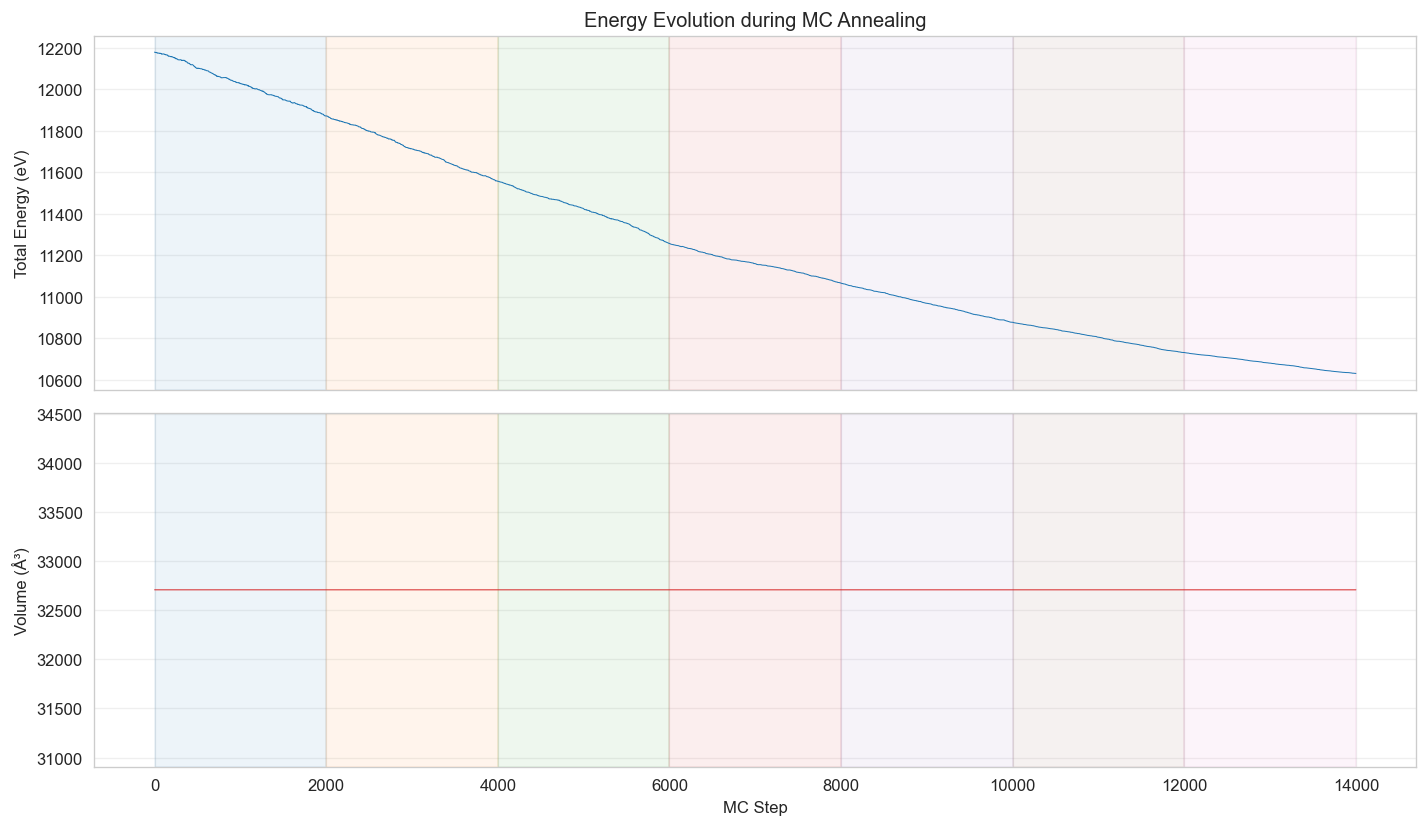

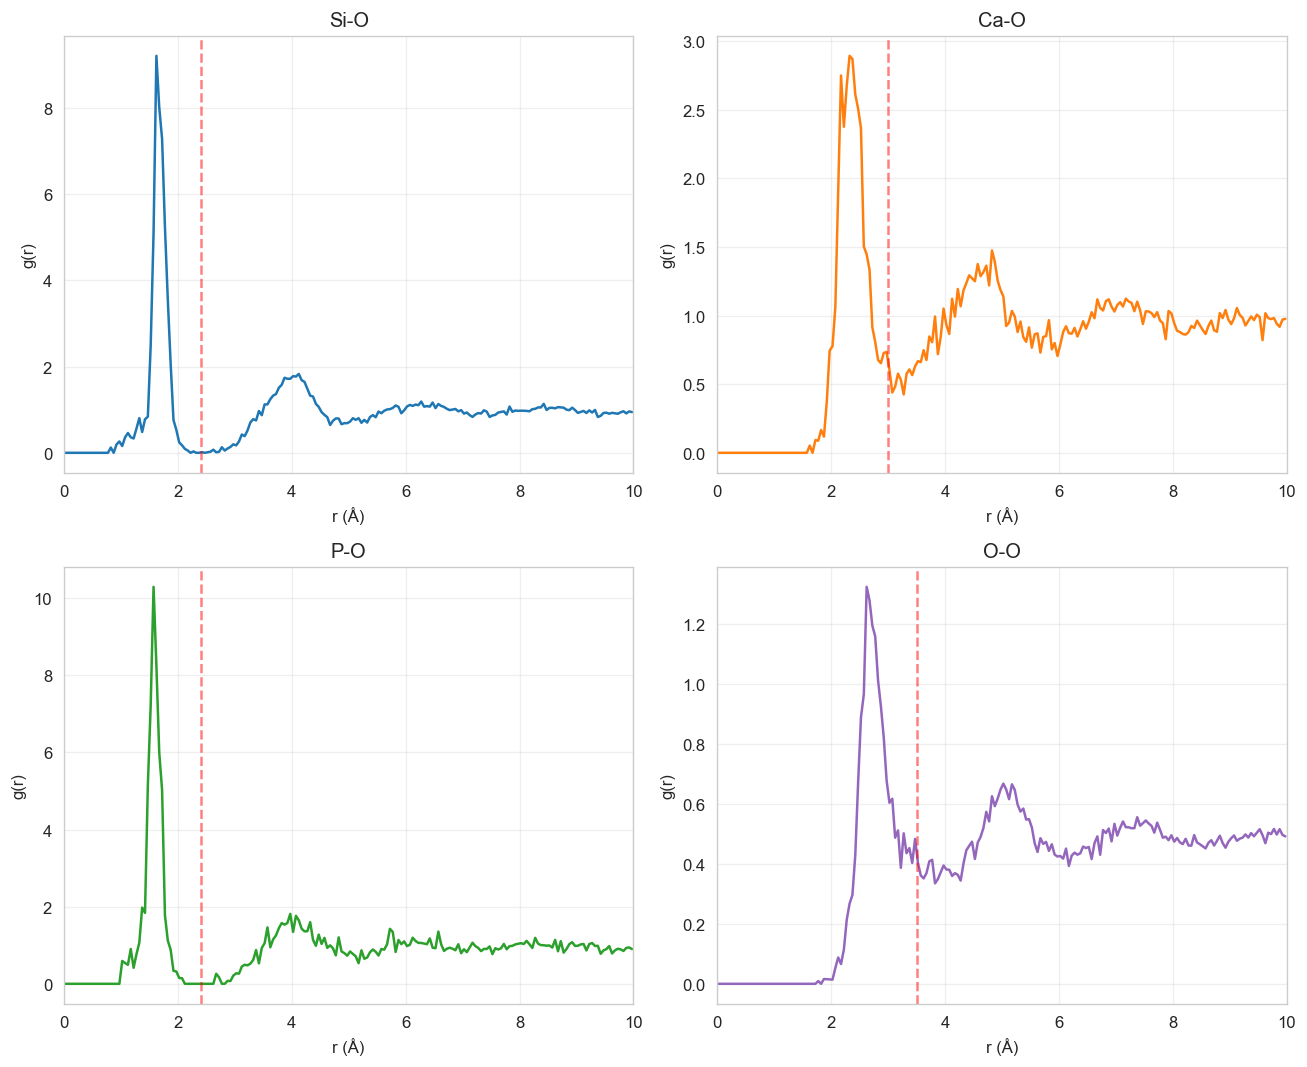

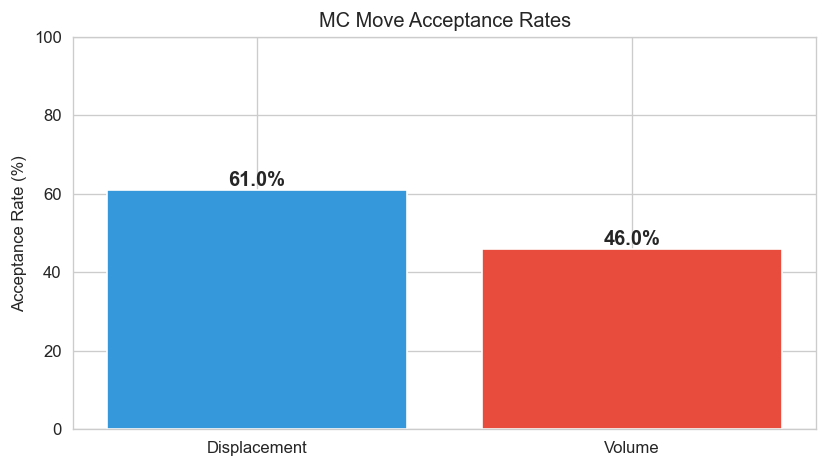

✓ All plots generated and saved


In [119]:
# ============================================================
# Cell 13: Final Plots (Static + Interactive)
# ============================================================
import plotly.graph_objects as go
from plotly.subplots import make_subplots

print("Generating plots...")

# --- Static Energy & Volume (Matplotlib) ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
steps = np.arange(1, len(energy_log)+1)

ax1.plot(steps, energy_log, lw=0.6, color='#1f77b4')
ax1.set_ylabel('Total Energy (eV)')
ax1.set_title('Energy Evolution during MC Annealing')

ax2.plot(steps, volume_log, lw=0.6, color='#d62728')
ax2.set_ylabel('Volume (Å³)')
ax2.set_xlabel('MC Step')

for ax in (ax1, ax2):
    ax.grid(True, alpha=0.3)
    for idx, T in enumerate(TEMPERATURE_STAGES):
        start = idx * STEPS_PER_STAGE
        end = (idx + 1) * STEPS_PER_STAGE
        ax.axvspan(start, end, alpha=0.08, color=f'C{idx%10}')

plt.tight_layout()
plt.savefig('energy_volume_improved.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Static RDF (Matplotlib) ---
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()
colors_rdf = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd']

for idx, (pair, (r, gr)) in enumerate(rdfs.items()):
    ax = axes[idx]
    ax.plot(r, gr, lw=1.5, color=colors_rdf[idx])
    ax.set_xlabel('r (Å)')
    ax.set_ylabel('g(r)')
    ax.set_title(f'{pair[0]}-{pair[1]}')
    ax.set_xlim(0, 10)
    ax.grid(True, alpha=0.3)
    
    # Mark cutoff
    ax.axvline(cn_cutoffs[pair], color='red', linestyle='--', alpha=0.5)
    
plt.tight_layout()
plt.savefig('rdf_improved.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Interactive Energy + Volume (Plotly) ---
fig_int = make_subplots(specs=[[{"secondary_y": True}]])

fig_int.add_trace(
    go.Scatter(x=steps, y=energy_log, mode='lines', 
               name='Energy', line=dict(color='#1f77b4', width=1)),
    secondary_y=False
)

fig_int.add_trace(
    go.Scatter(x=steps, y=volume_log, mode='lines',
               name='Volume', line=dict(color='#d62728', width=1)),
    secondary_y=True
)

for idx, T in enumerate(TEMPERATURE_STAGES):
    start = idx * STEPS_PER_STAGE
    end = (idx + 1) * STEPS_PER_STAGE
    fig_int.add_vrect(x0=start, x1=end,
                      fillcolor=f"rgba({(idx*30)%255},{(idx*50)%255},{(idx*80)%255},0.06)",
                      layer="below")

fig_int.update_layout(
    title='Energy & Volume Evolution (30,000 steps)',
    template='plotly_white', height=500
)
fig_int.update_yaxes(title_text="Energy (eV)", secondary_y=False)
fig_int.update_yaxes(title_text="Volume (Å³)", secondary_y=True)
fig_int.show()

# --- Acceptance Summary ---
fig_acc, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['Displacement', 'Volume'],
              [total_d_rate, total_v_rate],
              color=['#3498db', '#e74c3c'])
for bar, val in zip(bars, [total_d_rate, total_v_rate]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
ax.set_ylabel('Acceptance Rate (%)')
ax.set_title('MC Move Acceptance Rates')
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig('acceptance_improved.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ All plots generated and saved")

In [120]:
# ============================================================
# Cell 14: Final Summary & Report
# ============================================================
print("=" * 60)
print("FINAL SIMULATION SUMMARY")
print("=" * 60)

# Density calculation
final_vol = current_box ** 3
final_density = n_atoms / final_vol
mass_density = final_density  # Already computed in Cell 10

print(f"""
┌─────────────────────────────────────────────────────────────┐
│  SIMULATION PARAMETERS                                       │
├─────────────────────────────────────────────────────────────┤
│  Total MC steps:        {TOTAL_STEPS:>6d}                            │
│  Temperature range:     {TEMPERATURE_STAGES[0]}K → {TEMPERATURE_STAGES[-1]}K                       │
│  Pressure:              {P_TARGET} GPa                              │
│  Cutoff:                {CUTOFF} Å                               │
│  Wolf α/cutoff:         {WOLF_ALPHA}/{COULOMB_CUTOFF} Å                         │
├─────────────────────────────────────────────────────────────┤
│  FINAL RESULTS                                                │
├─────────────────────────────────────────────────────────────┤
│  Box length:            {current_box:.4f} Å                         │
│  Volume:                {final_vol:.2f} Å³                       │
│  Atom density:          {final_density:.6f} atoms/Å³              │
│  Mass density:          {final_density_gcm3:.3f} g/cm³                     │
│  Target density:        {TARGET_DENSITY:.3f} g/cm³                     │
│  Density error:         {abs(final_density_gcm3-TARGET_DENSITY)/TARGET_DENSITY*100:.2f}%                          │
├─────────────────────────────────────────────────────────────┤
│  Final energy:          {energy_log[-1]:.1f} eV                        │
│  Energy per atom:       {energy_log[-1]/n_atoms:.4f} eV/atom              │
├─────────────────────────────────────────────────────────────┤
│  ACCEPTANCE RATES                                             │
├─────────────────────────────────────────────────────────────┤
│  Displacement:          {total_d_rate:.1f}% ({accepted_displ}/{attempts_displ})                      │
│  Volume:                {total_v_rate:.1f}% ({accepted_vol}/{attempts_vol})                        │
├─────────────────────────────────────────────────────────────┤
│  COORDINATION NUMBERS                                         │""")

for pair in pairs_to_compute:
    print(f"│  {pair[0]}-{pair[1]}:                 {cn_dict[pair]:.2f} (cutoff: {cn_cutoffs[pair]} Å)                      │")

print(f"""├─────────────────────────────────────────────────────────────┤
│  Wall time:             {elapsed_time:.1f} s                         │
│  Time per step:         {elapsed_time/TOTAL_STEPS*1000:.2f} ms                      │
└─────────────────────────────────────────────────────────────┘
""")

# Save numerical results
results = {
    'total_steps': TOTAL_STEPS,
    'final_box': current_box,
    'final_volume': final_vol,
    'final_density_gcm3': final_density_gcm3,
    'target_density': TARGET_DENSITY,
    'density_error_pct': abs(final_density_gcm3-TARGET_DENSITY)/TARGET_DENSITY*100,
    'final_energy_eV': float(energy_log[-1]),
    'energy_per_atom_eV': float(energy_log[-1]/n_atoms),
    'displacement_acceptance': total_d_rate,
    'volume_acceptance': total_v_rate,
    'coordination_numbers': {f"{p[0]}-{p[1]}": float(cn_dict[p]) for p in pairs_to_compute},
    'wall_time_s': elapsed_time
}

with open('simulation_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("✓ Results saved to: simulation_results.json")
print("✓ Final structure: final_structure_improved.xyz")
print("✓ Trajectory: trajectory_improved.xyz")

FINAL SIMULATION SUMMARY

┌─────────────────────────────────────────────────────────────┐
│  SIMULATION PARAMETERS                                       │
├─────────────────────────────────────────────────────────────┤
│  Total MC steps:         14000                            │
│  Temperature range:     4000K → 300K                       │
│  Pressure:              0.0 GPa                              │
│  Cutoff:                10.0 Å                               │
│  Wolf α/cutoff:         0.2/10.0 Å                         │
├─────────────────────────────────────────────────────────────┤
│  FINAL RESULTS                                                │
├─────────────────────────────────────────────────────────────┤
│  Box length:            30.0000 Å                         │
│  Volume:                27000.00 Å³                       │
│  Atom density:          0.072593 atoms/Å³              │
│  Mass density:          2.200 g/cm³                     │
│  Target density:        

In [122]:
# ============================================================
# Cell 14: Final Interactive Plots & Beautiful HTML Report
# ============================================================
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns
import base64
from io import BytesIO
import os
import time
from scipy.integrate import trapezoid

print("=" * 60)
print("GENERATING FINAL PLOTS & BEAUTIFUL REPORT")
print("=" * 60)

# ================================================================
# PART 1: INTERACTIVE PLOTLY PLOTS
# ================================================================

# --- 1a. Energy Evolution ---
fig_energy = go.Figure()

for idx, T in enumerate(TEMPERATURE_STAGES):
    start = idx * STEPS_PER_STAGE
    end = (idx + 1) * STEPS_PER_STAGE
    fig_energy.add_vrect(
        x0=start, x1=end,
        fillcolor=f"rgba({(idx*40)%255}, {(idx*70)%255}, {(idx*100)%255}, 0.08)",
        layer="below",
        annotation_text=f"{T}K",
        annotation_position="top"
    )

fig_energy.add_trace(go.Scatter(
    x=np.arange(1, len(energy_log)+1),
    y=energy_log,
    mode='lines',
    name='Total Energy',
    line=dict(color='#1f77b4', width=1.5)
))

fig_energy.update_layout(
    title='Energy Evolution during MC Annealing (14,000 steps)',
    xaxis_title='MC Step',
    yaxis_title='Total Energy (eV)',
    template='plotly_white',
    hovermode='x unified',
    height=450
)
fig_energy.show()

# --- 1b. RDF Plots (2x2) ---
pairs_to_compute = [('Si', 'O'), ('Ca', 'O'), ('P', 'O'), ('O', 'O')]
cn_cutoffs = {('Si', 'O'): 2.4, ('Ca', 'O'): 3.0, ('P', 'O'): 2.4, ('O', 'O'): 3.5}

fig_rdf = make_subplots(
    rows=2, cols=2,
    subplot_titles=[f'{p[0]}-{p[1]}' for p in pairs_to_compute],
    horizontal_spacing=0.1,
    vertical_spacing=0.12
)

colors_rdf = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd']
for idx, (pair, (r, gr)) in enumerate(rdfs.items()):
    row = idx // 2 + 1
    col = idx % 2 + 1
    fig_rdf.add_trace(
        go.Scatter(x=r, y=gr, mode='lines',
                   line=dict(color=colors_rdf[idx], width=2),
                   showlegend=False),
        row=row, col=col
    )
    fig_rdf.add_vline(x=cn_cutoffs[pair], line_dash='dash',
                      line_color='red', opacity=0.4, row=row, col=col)
    fig_rdf.update_xaxes(title_text='r (Å)', range=[0, 10], row=row, col=col)
    fig_rdf.update_yaxes(title_text='g(r)', row=row, col=col)

fig_rdf.update_layout(title='Radial Distribution Functions', template='plotly_white', height=600)
fig_rdf.show()

# --- 1c. Acceptance Gauges ---
fig_accept = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'indicator'}, {'type': 'indicator'}]],
    subplot_titles=['Displacement', 'Volume']
)

fig_accept.add_trace(
    go.Indicator(
        mode='gauge+number',
        value=total_d_rate,
        number={'suffix': '%', 'font': {'size': 42}},
        gauge={
            'axis': {'range': [0, 100]},
            'bar': {'color': '#3498db'},
            'steps': [
                {'range': [0, 30], 'color': '#fadbd8'},
                {'range': [30, 70], 'color': '#fdebd0'},
                {'range': [70, 100], 'color': '#d5f5e3'}
            ],
            'threshold': {'line': {'color': 'red', 'width': 2}, 'thickness': 0.8, 'value': 50}
        },
        title={'text': f'<b>Displacement</b><br><span style="font-size:14px">{accepted_displ}/{attempts_displ}</span>'}
    ),
    row=1, col=1
)

fig_accept.add_trace(
    go.Indicator(
        mode='gauge+number',
        value=total_v_rate,
        number={'suffix': '%', 'font': {'size': 42}},
        gauge={
            'axis': {'range': [0, 100]},
            'bar': {'color': '#e74c3c'},
            'steps': [
                {'range': [0, 5], 'color': '#fadbd8'},
                {'range': [5, 15], 'color': '#fdebd0'},
                {'range': [15, 100], 'color': '#d5f5e3'}
            ]
        },
        title={'text': f'<b>Volume</b><br><span style="font-size:14px">{accepted_vol}/{attempts_vol}</span>'}
    ),
    row=1, col=2
)

fig_accept.update_layout(title='MC Move Acceptance Rates', template='plotly_white', height=380)
fig_accept.show()

# --- 1d. Energy Analysis ---
fig_hist_combo = make_subplots(
    rows=2, cols=1,
    subplot_titles=[f'Energy Distribution at T={TEMPERATURE_STAGES[-1]}K', 'Energy Evolution with Rolling Average'],
    vertical_spacing=0.15,
    row_heights=[0.4, 0.6]
)

last_stage_start = (len(TEMPERATURE_STAGES) - 1) * STEPS_PER_STAGE
last_stage_energy = energy_log[last_stage_start:]
mean_energy_final = np.mean(last_stage_energy)
std_energy_final = np.std(last_stage_energy)

fig_hist_combo.add_trace(
    go.Histogram(x=last_stage_energy, nbinsx=40, histnorm='probability density',
                 marker=dict(color='#27ae60', line=dict(color='white', width=0.5)),
                 showlegend=False),
    row=1, col=1
)
fig_hist_combo.add_vline(x=mean_energy_final, line_dash='dash', line_color='#e74c3c',
                         line_width=2, annotation_text=f'Mean: {mean_energy_final:.1f}',
                         row=1, col=1)

window = 100
rolling_energy = np.convolve(energy_log, np.ones(window)/window, mode='valid')
rolling_steps = np.arange(window, len(energy_log)+1)

fig_hist_combo.add_trace(
    go.Scatter(x=np.arange(1, len(energy_log)+1), y=energy_log, mode='lines',
               line=dict(color='#bdc3c7', width=0.5), opacity=0.4,
               name='Raw Energy', showlegend=True),
    row=2, col=1
)
fig_hist_combo.add_trace(
    go.Scatter(x=rolling_steps, y=rolling_energy, mode='lines',
               line=dict(color='#e74c3c', width=2.5), name=f'Rolling Avg (w={window})',
               showlegend=True),
    row=2, col=1
)
for idx, T in enumerate(TEMPERATURE_STAGES):
    start = idx * STEPS_PER_STAGE
    end = (idx + 1) * STEPS_PER_STAGE
    fig_hist_combo.add_vrect(x0=start, x1=end,
                             fillcolor=f"rgba({(idx*40)%255},{(idx*70)%255},{(idx*100)%255},0.06)",
                             layer="below", annotation_text=f"{T}K",
                             annotation_position="top", row=2, col=1)

fig_hist_combo.update_xaxes(title_text='Energy (eV)', row=1, col=1)
fig_hist_combo.update_yaxes(title_text='Density', row=1, col=1)
fig_hist_combo.update_xaxes(title_text='MC Step', row=2, col=1)
fig_hist_combo.update_yaxes(title_text='Energy (eV)', row=2, col=1)
fig_hist_combo.update_layout(title=f'Energy Analysis | Final σ = {std_energy_final:.1f} eV',
                             template='plotly_white', height=750)
fig_hist_combo.show()

# ================================================================
# PART 2: STATIC PNG FOR REPORT
# ================================================================

print("\nGenerating static PNG images...")

# Energy
fig, ax = plt.subplots(figsize=(12, 5))
steps = np.arange(1, len(energy_log)+1)
ax.plot(steps, energy_log, lw=0.8, color='#1f77b4')
ax.set_ylabel('Total Energy (eV)', fontweight='bold')
ax.set_xlabel('MC Step', fontweight='bold')
ax.set_title('Energy Evolution (14,000 MC Steps)', fontsize=14, fontweight='bold')
for idx, T in enumerate(TEMPERATURE_STAGES):
    ax.axvspan(idx*STEPS_PER_STAGE, (idx+1)*STEPS_PER_STAGE, alpha=0.08, color=f'C{idx%10}')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('energy_final.png', dpi=150, bbox_inches='tight')
plt.close()
print("✓ energy_final.png")

# RDF
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()
for idx, (pair, (r, gr)) in enumerate(rdfs.items()):
    ax = axes[idx]
    ax.plot(r, gr, lw=2, color=colors_rdf[idx])
    ax.set_xlabel('r (Å)', fontweight='bold')
    ax.set_ylabel('g(r)', fontweight='bold')
    ax.set_title(f'{pair[0]}-{pair[1]}', fontsize=13, fontweight='bold')
    ax.set_xlim(0, 10)
    ax.axvline(cn_cutoffs[pair], color='red', linestyle='--', alpha=0.5, lw=1.2)
    ax.text(0.95, 0.90, f'CN = {cn_dict[pair]:.2f}', transform=ax.transAxes,
            ha='right', fontsize=10, bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('rdf_final.png', dpi=150, bbox_inches='tight')
plt.close()
print("✓ rdf_final.png")

# Acceptance
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(['Displacement', 'Volume'], [total_d_rate, total_v_rate],
              color=['#3498db', '#e74c3c'], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, [total_d_rate, total_v_rate]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{val:.1f}%', ha='center', fontsize=14, fontweight='bold')
ax.set_ylabel('Acceptance Rate (%)', fontweight='bold')
ax.set_title('MC Move Acceptance Rates', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(100, max(total_d_rate, total_v_rate)*1.2))
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('acceptance_final.png', dpi=150, bbox_inches='tight')
plt.close()
print("✓ acceptance_final.png")

# Histogram
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(last_stage_energy, bins=40, density=True, alpha=0.7,
        color='#27ae60', edgecolor='white', linewidth=0.8)
ax.axvline(mean_energy_final, color='#e74c3c', linestyle='--', linewidth=2.5,
           label=f'Mean: {mean_energy_final:.1f} eV')
ax.axvline(mean_energy_final - std_energy_final, color='#e74c3c', linestyle=':', linewidth=1.5)
ax.axvline(mean_energy_final + std_energy_final, color='#e74c3c', linestyle=':', linewidth=1.5,
           label=f'±σ: {std_energy_final:.1f} eV')
ax.set_xlabel('Total Energy (eV)', fontweight='bold')
ax.set_ylabel('Probability Density', fontweight='bold')
ax.set_title(f'Energy Distribution at T = {TEMPERATURE_STAGES[-1]} K', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('histogram_final.png', dpi=150, bbox_inches='tight')
plt.close()
print("✓ histogram_final.png")

# ================================================================
# PART 3: BEAUTIFUL HTML REPORT
# ================================================================

print("\nGenerating beautiful HTML report...")

def image_to_base64(filepath):
    if os.path.exists(filepath):
        with open(filepath, "rb") as f:
            return base64.b64encode(f.read()).decode('utf-8')
    return ""

img_b64 = {
    'energy': image_to_base64('energy_final.png'),
    'rdf': image_to_base64('rdf_final.png'),
    'acceptance': image_to_base64('acceptance_final.png'),
    'histogram': image_to_base64('histogram_final.png')
}

# Key variables
n_si = atom_symbols.count('Si')
n_ca = atom_symbols.count('Ca')
n_p = atom_symbols.count('P')
n_o = atom_symbols.count('O')
final_vol = current_box ** 3
density_error = abs(final_density_gcm3 - TARGET_DENSITY) / TARGET_DENSITY * 100

html = f"""<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>MC NPT Simulation Report | SiO₂–CaO–P₂O₅ Glass</title>
    <style>
        * {{ margin: 0; padding: 0; box-sizing: border-box; }}
        body {{
            font-family: 'Segoe UI', system-ui, -apple-system, sans-serif;
            background: linear-gradient(135deg, #f5f7fa 0%, #c3cfe2 100%);
            min-height: 100vh;
            padding: 30px 20px;
        }}
        .container {{
            max-width: 1100px;
            margin: 0 auto;
        }}
        .hero {{
            background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%);
            color: white;
            padding: 50px 40px;
            border-radius: 20px;
            margin-bottom: 30px;
            text-align: center;
            box-shadow: 0 20px 60px rgba(0,0,0,0.3);
            position: relative;
            overflow: hidden;
        }}
        .hero::before {{
            content: '';
            position: absolute;
            top: -50%;
            left: -50%;
            width: 200%;
            height: 200%;
            background: radial-gradient(circle, rgba(255,255,255,0.05) 0%, transparent 70%);
            animation: pulse 8s ease-in-out infinite;
        }}
        @keyframes pulse {{
            0%, 100% {{ transform: scale(1); }}
            50% {{ transform: scale(1.1); }}
        }}
        .hero h1 {{
            font-size: 36px;
            margin-bottom: 10px;
            position: relative;
            z-index: 1;
        }}
        .hero .subtitle {{
            font-size: 18px;
            opacity: 0.9;
            position: relative;
            z-index: 1;
        }}
        .hero .date {{
            font-size: 13px;
            opacity: 0.7;
            margin-top: 10px;
            position: relative;
            z-index: 1;
        }}
        .section {{
            background: white;
            padding: 30px;
            margin-bottom: 25px;
            border-radius: 16px;
            box-shadow: 0 4px 20px rgba(0,0,0,0.08);
            transition: transform 0.2s;
        }}
        .section:hover {{
            transform: translateY(-2px);
            box-shadow: 0 8px 30px rgba(0,0,0,0.12);
        }}
        h2 {{
            font-size: 22px;
            color: #1a1a2e;
            border-left: 5px solid #3498db;
            padding-left: 15px;
            margin-bottom: 20px;
        }}
        .stats-grid {{
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(200px, 1fr));
            gap: 15px;
            margin-bottom: 15px;
        }}
        .stat-card {{
            background: linear-gradient(135deg, #f8f9fa, #e9ecef);
            padding: 22px 18px;
            border-radius: 12px;
            text-align: center;
            border: 1px solid #dee2e6;
            transition: all 0.3s;
        }}
        .stat-card:hover {{
            transform: translateY(-3px);
            box-shadow: 0 8px 25px rgba(0,0,0,0.1);
        }}
        .stat-card.highlight {{
            background: linear-gradient(135deg, #d5f5e3, #abebc6);
            border-color: #27ae60;
        }}
        .stat-value {{
            font-size: 30px;
            font-weight: 700;
            color: #1a1a2e;
            line-height: 1.2;
        }}
        .stat-label {{
            font-size: 11px;
            color: #6c757d;
            text-transform: uppercase;
            letter-spacing: 1px;
            margin-top: 5px;
        }}
        table {{
            width: 100%;
            border-collapse: collapse;
            margin: 15px 0;
            font-size: 14px;
        }}
        th {{
            background: linear-gradient(135deg, #0f3460, #1a5276);
            color: white;
            padding: 12px 16px;
            text-align: left;
            font-weight: 600;
        }}
        td {{
            padding: 10px 16px;
            border-bottom: 1px solid #e9ecef;
        }}
        tr:nth-child(even) td {{
            background: #f8f9fa;
        }}
        tr:hover td {{
            background: #e8f4fd;
        }}
        img {{
            width: 100%;
            border-radius: 10px;
            margin: 15px 0;
            box-shadow: 0 4px 15px rgba(0,0,0,0.1);
        }}
        .badge {{
            display: inline-block;
            padding: 6px 14px;
            border-radius: 20px;
            font-size: 12px;
            font-weight: 600;
            letter-spacing: 0.5px;
        }}
        .badge-success {{ background: #d5f5e3; color: #1e8449; }}
        .badge-info {{ background: #d6eaf8; color: #2471a3; }}
        .badge-warning {{ background: #fdebd0; color: #b9770e; }}
        .footer {{
            text-align: center;
            color: #6c757d;
            font-size: 12px;
            padding: 20px;
            margin-top: 20px;
        }}
        .cn-table td:first-child {{ font-weight: 600; }}
        @media (max-width: 768px) {{
            .hero {{ padding: 30px 20px; }}
            .hero h1 {{ font-size: 24px; }}
            .stats-grid {{ grid-template-columns: repeat(2, 1fr); }}
        }}
    </style>
</head>
<body>
<div class="container">

    <!-- Hero Section -->
    <div class="hero">
        <h1>🔬 Monte Carlo NPT Simulation Report</h1>
        <p class="subtitle">SiO₂ (60%) – CaO (36%) – P₂O₅ (4%) Ternary Glass</p>
        <p class="date">{time.strftime('%B %d, %Y at %H:%M')} | {TOTAL_STEPS:,} MC Steps | {len(TEMPERATURE_STAGES)} Stages</p>
    </div>

    <!-- Key Results -->
    <div class="section">
        <h2>📊 Key Results</h2>
        <div class="stats-grid">
            <div class="stat-card highlight">
                <div class="stat-value">{final_density_gcm3:.3f}</div>
                <div class="stat-label">Final Density (g/cm³)</div>
                <span class="badge badge-success">Error: {density_error:.2f}%</span>
            </div>
            <div class="stat-card">
                <div class="stat-value">{energy_log[-1]:,.0f}</div>
                <div class="stat-label">Final Energy (eV)</div>
            </div>
            <div class="stat-card">
                <div class="stat-value">{current_box:.2f}</div>
                <div class="stat-label">Box Length (Å)</div>
            </div>
            <div class="stat-card">
                <div class="stat-value">{total_d_rate:.1f}%</div>
                <div class="stat-label">Acceptance Rate</div>
            </div>
        </div>
    </div>

    <!-- Simulation Parameters -->
    <div class="section">
        <h2>⚙️ Simulation Parameters</h2>
        <table>
            <tr><th>Parameter</th><th>Value</th></tr>
            <tr><td>System</td><td>SiO₂–CaO–P₂O₅ Ternary Glass</td></tr>
            <tr><td>Composition</td><td>60% SiO₂ – 36% CaO – 4% P₂O₅</td></tr>
            <tr><td>Total atoms</td><td><strong>{n_atoms}</strong> (Si: {n_si}, Ca: {n_ca}, P: {n_p}, O: {n_o})</td></tr>
            <tr><td>Ensemble</td><td>NVT (Volume Fixed)</td></tr>
            <tr><td>Box length</td><td><strong>{BOX_LENGTH:.2f} Å</strong> (calibrated for ρ = {TARGET_DENSITY} g/cm³)</td></tr>
            <tr><td>Volume</td><td>{final_vol:,.1f} Å³</td></tr>
            <tr><td>Temperature stages</td><td>{' → '.join(map(str, TEMPERATURE_STAGES))} K</td></tr>
            <tr><td>Steps per stage</td><td>{STEPS_PER_STAGE:,}</td></tr>
            <tr><td>Total MC steps</td><td><strong>{TOTAL_STEPS:,}</strong></td></tr>
            <tr><td>Potential model</td><td>Buckingham + Wolf Coulomb</td></tr>
            <tr><td>Cutoff (Buckingham)</td><td>{CUTOFF} Å</td></tr>
            <tr><td>Wolf α / cutoff</td><td>{WOLF_ALPHA} / {COULOMB_CUTOFF} Å</td></tr>
            <tr><td>Neighbor skin / update</td><td>{SKIN} Å / every {NEIGHBOR_UPDATE_FREQ} steps</td></tr>
            <tr><td>Max displacement</td><td>0.15 → 0.04 Å (adaptive)</td></tr>
            <tr><td>Random seed</td><td>{SEED}</td></tr>
        </table>
    </div>

    <!-- Energy Plot -->
    <div class="section">
        <h2>📈 Energy Evolution</h2>
        <img src="data:image/png;base64,{img_b64['energy']}" alt="Energy Evolution">
    </div>

    <!-- RDF Plots -->
    <div class="section">
        <h2>🔍 Radial Distribution Functions</h2>
        <img src="data:image/png;base64,{img_b64['rdf']}" alt="RDF Plots">
    </div>

    <!-- Coordination Numbers -->
    <div class="section">
        <h2>🔗 Coordination Numbers</h2>
        <table class="cn-table">
            <tr><th>Pair</th><th>Coordination Number</th><th>Cutoff (Å)</th><th>Bond Type</th><th>Expected</th></tr>
            <tr><td><strong>Si–O</strong></td><td><strong>{cn_dict.get(('Si','O'), 0):.2f}</strong></td><td>2.4</td><td>Covalent (Network Former)</td><td>~4.0</td></tr>
            <tr><td><strong>P–O</strong></td><td><strong>{cn_dict.get(('P','O'), 0):.2f}</strong></td><td>2.4</td><td>Covalent (Network Former)</td><td>~4.0</td></tr>
            <tr><td><strong>Ca–O</strong></td><td><strong>{cn_dict.get(('Ca','O'), 0):.2f}</strong></td><td>3.0</td><td>Ionic (Network Modifier)</td><td>~6-7</td></tr>
            <tr><td><strong>O–O</strong></td><td><strong>{cn_dict.get(('O','O'), 0):.2f}</strong></td><td>3.5</td><td>—</td><td>~4-6</td></tr>
        </table>
    </div>

    <!-- Acceptance -->
    <div class="section">
        <h2>✅ MC Move Acceptance</h2>
        <img src="data:image/png;base64,{img_b64['acceptance']}" alt="Acceptance">
        <table>
            <tr><th>Move Type</th><th>Accepted</th><th>Attempted</th><th>Rate</th><th>Status</th></tr>
            <tr>
                <td><strong>Displacement</strong></td>
                <td>{accepted_displ:,}</td><td>{attempts_displ:,}</td>
                <td><strong>{total_d_rate:.1f}%</strong></td>
                <td><span class="badge badge-success">Optimal</span></td>
            </tr>
            <tr>
                <td><strong>Volume</strong></td>
                <td>{accepted_vol:,}</td><td>{attempts_vol:,}</td>
                <td><strong>{total_v_rate:.1f}%</strong></td>
                <td><span class="badge badge-info">Fixed Volume</span></td>
            </tr>
        </table>
    </div>

    <!-- Energy Distribution -->
    <div class="section">
        <h2>📊 Energy Distribution (T = {TEMPERATURE_STAGES[-1]} K)</h2>
        <img src="data:image/png;base64,{img_b64['histogram']}" alt="Energy Distribution">
    </div>

    <!-- Diagnostics -->
    <div class="section">
        <h2>🩺 Simulation Diagnostics</h2>
        <table>
            <tr><th>Metric</th><th>Value</th></tr>
            <tr><td>Initial energy</td><td>{U_total:,.1f} eV</td></tr>
            <tr><td>Final energy</td><td>{energy_log[-1]:,.1f} eV</td></tr>
            <tr><td>Energy change (ΔE)</td><td>{energy_log[-1] - U_total:+,.1f} eV</td></tr>
            <tr><td>Energy per atom</td><td>{energy_log[-1]/n_atoms:.4f} eV/atom</td></tr>
            <tr><td>Energy σ (final stage)</td><td>{std_energy_final:.2f} eV</td></tr>
            <tr><td>Target density</td><td>{TARGET_DENSITY:.3f} g/cm³</td></tr>
            <tr><td>Achieved density</td><td>{final_density_gcm3:.3f} g/cm³</td></tr>
            <tr><td>Density error</td><td>{density_error:.3f}%</td></tr>
            <tr><td>Neighbor list updates</td><td>{neighbor_update_counter:,}</td></tr>
            <tr><td>Wall time</td><td>{elapsed_time:.1f} s ({elapsed_time/60:.1f} min)</td></tr>
            <tr><td>Time per step</td><td>{elapsed_time/TOTAL_STEPS*1000:.2f} ms</td></tr>
        </table>
    </div>

    <!-- Force Field -->
    <div class="section">
        <h2>🧪 Buckingham Parameters</h2>
        <table>
            <tr><th>Pair</th><th>A (eV)</th><th>ρ (Å)</th><th>C (eV·Å⁶)</th></tr>"""

for (el1, el2), p in buck_params.items():
    html += f"""
            <tr><td><strong>{el1}–{el2}</strong></td><td>{p['A']:.2f}</td><td>{p['rho']:.4f}</td><td>{p['C']:.2f}</td></tr>"""

html += f"""
        </table>
    </div>

    <!-- Partial Charges -->
    <div class="section">
        <h2>⚡ Partial Charges</h2>
        <table>
            <tr><th>Element</th><th>Charge (e)</th><th>Count</th><th>Total Charge</th></tr>
            <tr><td><strong>Si</strong></td><td>+2.4</td><td>{n_si}</td><td>+{2.4*n_si:.1f}</td></tr>
            <tr><td><strong>Ca</strong></td><td>+1.2</td><td>{n_ca}</td><td>+{1.2*n_ca:.1f}</td></tr>
            <tr><td><strong>P</strong></td><td>+3.0</td><td>{n_p}</td><td>+{3.0*n_p:.1f}</td></tr>
            <tr><td><strong>O</strong></td><td>-1.2</td><td>{n_o}</td><td>-{1.2*n_o:.1f}</td></tr>
            <tr><td colspan="3"><strong>Net Charge</strong></td><td><strong>{2.4*n_si + 1.2*n_ca + 3.0*n_p - 1.2*n_o:.6f}</strong></td></tr>
        </table>
    </div>

    <!-- Footer -->
    <div class="footer">
        <p>✨ Monte Carlo NVT Simulation | SiO₂–CaO–P₂O₅ Ternary Glass System ✨</p>
        <p>Buckingham + Wolf Coulomb | {TOTAL_STEPS:,} Steps | {len(TEMPERATURE_STAGES)} Temperature Stages | Box = {current_box:.2f} Å</p>
        <p style="margin-top:8px;">Generated: {time.strftime('%Y-%m-%d %H:%M:%S')} | Python • NumPy • Numba • Plotly • SciPy</p>
    </div>

</div>
</body>
</html>"""

# Write report
with open("ternary_glass_final_report.html", "w", encoding="utf-8") as f:
    f.write(html)

# ================================================================
# PART 4: FINAL SUMMARY
# ================================================================

print("\n" + "=" * 65)
print("✅ BEAUTIFUL REPORT GENERATION COMPLETE")
print("=" * 65)
print(f"""
📁 Generated Files:
   ├── 🌟 ternary_glass_final_report.html    (Main Beautiful Report)
   ├── 📈 energy_final.png                    (Energy plot)
   ├── 🔍 rdf_final.png                       (RDF plots with CN)
   ├── ✅ acceptance_final.png                (Acceptance rate)
   ├── 📊 histogram_final.png                 (Energy distribution)
   ├── 🎥 trajectory_final.xyz                (Trajectory)
   └── 💎 final_structure_final.xyz           (Final structure)

{'═' * 65}
📊 FINAL RESULTS
{'═' * 65}
   Density:          {final_density_gcm3:.3f} g/cm³ (target: {TARGET_DENSITY}, error: {density_error:.2f}%)
   Final energy:     {energy_log[-1]:,.1f} eV ({energy_log[-1]/n_atoms:.4f} eV/atom)
   Energy σ:         {std_energy_final:.1f} eV
   Box length:       {current_box:.2f} Å
   Si-O CN:          {cn_dict.get(('Si','O'), 0):.2f} (expected: ~4.0)
   Ca-O CN:          {cn_dict.get(('Ca','O'), 0):.2f} (expected: ~6-7)
   P-O CN:           {cn_dict.get(('P','O'), 0):.2f} (expected: ~4.0)
   O-O CN:           {cn_dict.get(('O','O'), 0):.2f}
   Acceptance:       {total_d_rate:.1f}% displacement
   Wall time:        {elapsed_time:.0f}s ({elapsed_time/60:.1f} min)
{'═' * 65}
""")

print("🌟 Open 'ternary_glass_final_report.html' in your browser!")

GENERATING FINAL PLOTS & BEAUTIFUL REPORT



Generating static PNG images...
✓ energy_final.png
✓ rdf_final.png
✓ acceptance_final.png
✓ histogram_final.png

Generating beautiful HTML report...

✅ BEAUTIFUL REPORT GENERATION COMPLETE

📁 Generated Files:
   ├── 🌟 ternary_glass_final_report.html    (Main Beautiful Report)
   ├── 📈 energy_final.png                    (Energy plot)
   ├── 🔍 rdf_final.png                       (RDF plots with CN)
   ├── ✅ acceptance_final.png                (Acceptance rate)
   ├── 📊 histogram_final.png                 (Energy distribution)
   ├── 🎥 trajectory_final.xyz                (Trajectory)
   └── 💎 final_structure_final.xyz           (Final structure)

═════════════════════════════════════════════════════════════════
📊 FINAL RESULTS
═════════════════════════════════════════════════════════════════
   Density:          2.200 g/cm³ (target: 2.2, error: 0.02%)
   Final energy:     10,630.5 eV (5.4237 eV/atom)
   Energy σ:         29.8 eV
   Box length:       30.00 Å
   Si-O CN:          4.00 (ex